<a href="https://colab.research.google.com/github/BintangPancahaya/PemMes_2026/blob/main/JS05/JS05_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv('spam.csv', encoding='latin-1')

# hanya kolom v1 (label) dan v2 (teks) yang dipakai, kolom lain kosong
data = data[['v1', 'v2']]
data.columns = ['label', 'text']
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
data.info()
print(data.isnull().sum())
data['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
label    0
text     0
dtype: int64


,count
label,
ham,4825
spam,747


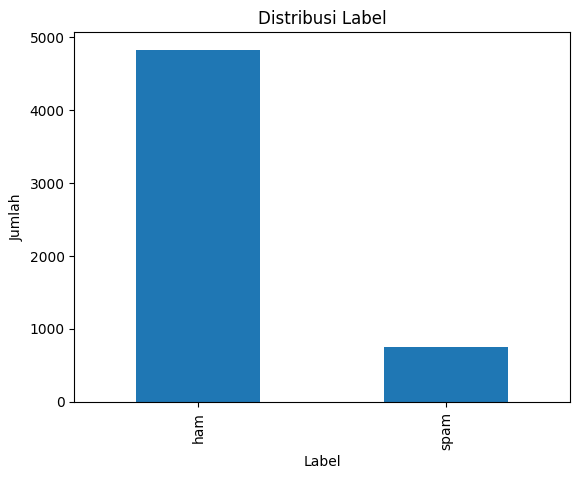

In [3]:
import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')
plt.title('Distribusi Label')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(len(X_train), 'data training')
print(len(X_test), 'data testing')

4457 data training
1115 data testing


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# ekstraksi fitur Count Vectorizer dengan stop_words aktif
cv = CountVectorizer(stop_words='english')
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)
print('Jumlah fitur (kata):', X_train_cv.shape[1])

# model
nb_cv = MultinomialNB()
nb_cv.fit(X_train_cv, y_train)

# evaluasi
y_pred_cv = nb_cv.predict(X_test_cv)
print('Akurasi:', accuracy_score(y_test, y_pred_cv))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_cv))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred_cv))

Jumlah fitur (kata): 7440
Akurasi: 0.9838565022421525
Confusion Matrix:
 [[960   6]
 [ 12 137]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ekstraksi fitur TF-IDF dengan stop_words aktif
tfidf = TfidfVectorizer(stop_words='english')
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)
print('Jumlah fitur (kata):', X_train_tf.shape[1])

# model
nb_tf = MultinomialNB()
nb_tf.fit(X_train_tf, y_train)

# evaluasi
y_pred_tf = nb_tf.predict(X_test_tf)
print('Akurasi:', accuracy_score(y_test, y_pred_tf))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_tf))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred_tf))

Jumlah fitur (kata): 7440
Akurasi: 0.968609865470852
Confusion Matrix:
 [[966   0]
 [ 35 114]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



             Metrik  CountVectorizer  TF-IDF
0           Akurasi           0.9839  0.9686
1  Precision (spam)           0.9580  1.0000
2     Recall (spam)           0.9195  0.7651
3   F1-score (spam)           0.9384  0.8669


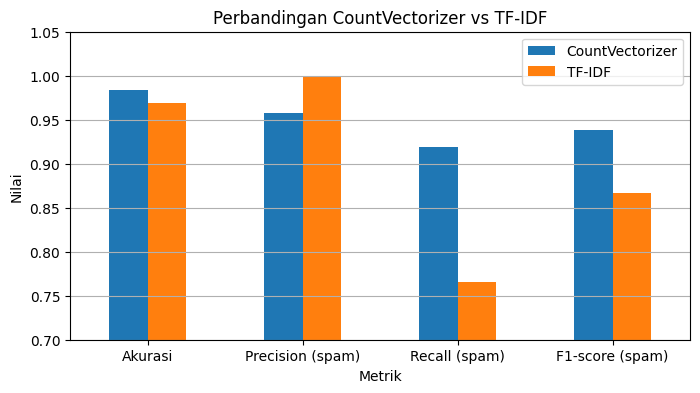

In [7]:
hasil = pd.DataFrame({
    'Metrik': ['Akurasi', 'Precision (spam)', 'Recall (spam)', 'F1-score (spam)'],
    'CountVectorizer': [accuracy_score(y_test, y_pred_cv),
                        precision_score(y_test, y_pred_cv, pos_label='spam'),
                        recall_score(y_test, y_pred_cv, pos_label='spam'),
                        f1_score(y_test, y_pred_cv, pos_label='spam')],
    'TF-IDF': [accuracy_score(y_test, y_pred_tf),
               precision_score(y_test, y_pred_tf, pos_label='spam'),
               recall_score(y_test, y_pred_tf, pos_label='spam'),
               f1_score(y_test, y_pred_tf, pos_label='spam')]
})
hasil = hasil.round(4)
print(hasil)

hasil.set_index('Metrik').plot(kind='bar', figsize=(8, 4))
plt.title('Perbandingan CountVectorizer vs TF-IDF')
plt.ylabel('Nilai')
plt.ylim(0.7, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## Kesimpulan
Fitur terbaik pada data `spam.csv` adalah **CountVectorizer**.

Alasan:
- Akurasi CountVectorizer 98,39% lebih tinggi daripada TF-IDF 96,86%.
- Recall spam CountVectorizer 91,95% jauh lebih tinggi daripada TF-IDF 76,51%. Artinya CountVectorizer berhasil menangkap lebih banyak SMS spam (hanya 12 spam lolos, sedangkan TF-IDF meloloskan 35 spam).
- F1-score spam CountVectorizer 93,84% jauh lebih baik daripada TF-IDF 86,69%.
- TF-IDF memang memiliki precision 100% (tidak ada ham yang salah dianggap spam), tetapi hasil itu dibayar dengan banyaknya spam yang tidak terdeteksi. Pada kasus filter spam, kedua jenis kesalahan perlu seimbang, sehingga F1-score menjadi acuan yang lebih adil dan CountVectorizer unggul.
- Kemungkinan penyebabnya: kata-kata pemicu spam seperti `free`, `call`, `txt`, dan `claim` muncul berulang kali pada pesan spam. Frekuensi mentah dari CountVectorizer menangkap pola ini dengan baik, sedangkan pembobotan TF-IDF menurunkan bobot kata yang sering muncul.
